<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller: Identificando  Burger Master con MMG

El Burger Master es un evento creado en el 2016 por el *influencer* Tulio Zuluaga, más conocido en redes como Tulio recomienda, el cual busca que por una semana las hamburgueserías de cada ciudad ofrezcan su mejor producto a un precio reducido. 

El evento ha venido creciendo y en el 2022 se extendió por 21 ciudades de Colombia para las cuales se estimó que se vendieron más de dos millones de hamburguesas. El objetivo del presente caso-taller  es identificar los puntos calientes de hamburgueserías  que compitieron en  la ciudad de Bogotá aplicando el Modelo de Mezclas Gaussianas.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "Revisión por el compañero."

4. El archivo entregado debe poder ser ejecutado localmente por los pares. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos  en la misma ruta de acceso del cuaderno, por ejemplo: `data`.


## Desarrollo

### 1. Carga de datos  

En la carpeta `data` se encuentra el archivo `burger_master.xlsx` para la ciudad de Bogotá, cargue estos datos en su *cuaderno* y reporte brevemente el contenido de la base.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
!pip install openpyxl


[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: pip install --upgrade pip


In [3]:
data_df = pd.read_excel("data/burger_master.xlsx")
data_df.head(5)

,Restaurante,Dirección,Descripción,Latitud,Longitud
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.668833,-74.116828
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.698395,-74.036585
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.686401,-74.060144
3,FRENCHEESE,Calle 51 #22-55,"<p>Presentamos «La French Master», inspirada e...",4.639514,-74.073545
4,FRENCHEESE,Calle 80 #14-41,"<p>Presentamos «La French Master», inspirada e...",4.666147,-74.056758


In [4]:
print("cantidad de locales participantes: {}".format(data_df.shape[0]))
print("cantidad de restaurantes/franquicias participantes: {}".format(len(data_df["Restaurante"].unique())))
print()
print("cantidad de direcciones unicas {}".format(len(data_df["Dirección"].unique())))

cantidad de locales participantes: 137
cantidad de restaurantes/franquicias participantes: 63

cantidad de direcciones unicas 116


**Eliminar Duplicados**

In [5]:
data_df = data_df.drop_duplicates()
print("cantidad de locales participantes: {}".format(data_df.shape[0]))
print("cantidad de restaurantes/franquicias participantes: {}".format(len(data_df["Restaurante"].unique())))
print()
print("cantidad de direcciones unicas {}".format(len(data_df["Dirección"].unique())))

cantidad de locales participantes: 116
cantidad de restaurantes/franquicias participantes: 63

cantidad de direcciones unicas 116


In [6]:
data_gp = gpd.GeoDataFrame(data_df, geometry = gpd.points_from_xy(data_df.Longitud, data_df.Latitud))
data_gp.head()

,Restaurante,Dirección,Descripción,Latitud,Longitud,geometry
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.668833,-74.116828,POINT (-74.11683 4.66883)
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.698395,-74.036585,POINT (-74.03658 4.69839)
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.686401,-74.060144,POINT (-74.06014 4.68640)
3,FRENCHEESE,Calle 51 #22-55,"<p>Presentamos «La French Master», inspirada e...",4.639514,-74.073545,POINT (-74.07355 4.63951)
4,FRENCHEESE,Calle 80 #14-41,"<p>Presentamos «La French Master», inspirada e...",4.666147,-74.056758,POINT (-74.05676 4.66615)


**columna Descripcion** \
se separan todos los valores almacenados, y se procede a encontrar la distribucion de la cantidad de valores almacenados en la columna descripcion

In [7]:
data_gp["Descripción"].str.split("<br/>")[0]

['<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana',
 '',
 'Cra 75 # 24D – 48, Modelia',
 'Calle 119 # 11A – 24, Santa Bárbara',
 'Cra 47A # 98 – 47, Castellana</p>']

Esta columna tiene informacion almacenada en formato html a continuacion se muestra la distribucion de la cantidad de caracteristicas almacenadas

In [8]:
data_gp["Descripción"].str.split("<br/>").apply(lambda x: len(x)).value_counts().sum(axis=0)

116

In [9]:
data_gp["Descripción"].str.split("<br/>").apply(lambda x: len(x)).value_counts()

1     44
5     17
13    11
4     10
10    10
6      8
9      7
8      6
7      3
Name: Descripción, dtype: int64

Se observa que 45 de los 137 participantes cuentan con al menos 1 caracteristica, el resto cuenta con 13 o mas caracteristicas. de todas estas la primera es la descripcion de la hamburguesa

In [10]:
data_gp["Descripción"].str.split("<br/>")[10]

['<p>En familia logramos componer una hamburguesa llena de sabor colombiano… Les presentamos LA CAQUETÁ: Hecha 100% con carne de res madurada súper jugosa; agregamos un toque cremoso y picante con nuestro alioli de aguacate; pico de gallo de cebolla, limón y repollo que aporta frescura y acidez; el sabor ahumado de nuestra tocineta y queso cheddar fundido. Con el propósito de resaltar nuestra cultura, adicionamos un autóctono chicharrón de queso Caquetá salado, gratinado con panela espolvoreada para darle el toque dulce de nuestra tierra.',
 '',
 'Autopista norte #146-48, Cedritos',
 'Av. Cra 24 #39B-20, Parkway',
 'Av. Calle 100#50-08, Pasadena',
 'Carrera 59a #136-95, Mall 138',
 'Cra 73a #51a-97, Normandía',
 'Av. Cra 45 #183a-66, C.C Autopista 184</p>']

**Conclusiones**
La base tenia registros duplicados que fue necesario eliminar, luego de esto se obtienen que existen 116 locales comerciales que participan en burguer master, de estos hay 63 marcas unicas participantes. los registros contienen una descripcion de la hamburguesa participante en la columna *Descripcion*

### 2.  Visualizando los datos

Visualice la ubicación de cada restaurante en un mapa interactivo. Añada un marcador para cada restaurante y la posibilidad de encontrar la descripción de la hamburguesa ofrecida en un pop-up. (Note que la columna Descripción contiene otra información adicional).

In [11]:
# encontrar la descrupcion de la hamburguesa
data_gp["descripcion_hamburguesa"] = data_gp["Descripción"].str.split("<br/>").str[0].str.replace("<p>","")

In [12]:
#importamos la librería
import folium

#Mapa base
map = folium.Map(location = [data_gp.Latitud.mean(), data_gp.Longitud.mean()], tiles = "OpenStreetMap", zoom_start = 10)
# Otras opciones de tiles
#Stamen Terrain, Toner, and Watercolor

#capa teatros
for i in range(0,len(data_gp)):
   folium.Marker(
      location=[data_gp.iloc[i]['Latitud'], data_gp.iloc[i]['Longitud']],
      popup=data_gp.iloc[i]['descripcion_hamburguesa']
   ).add_to(map)


#Display el mapa
map

In [13]:
!pip install folium matplotlib mapclassify


[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: pip install --upgrade pip


Encontrar la limitacion de la ciudad de bogota, sin embargo luego de validar con los monitores, no hay necesidad de limitar los restaurantes solo a la zona de bogota

In [14]:
from pyrosm import OSM, get_data

fp = get_data("Bogota")

# Inicializamos el lector para Buenos Aires
osm = OSM(fp)
capital= osm.get_boundaries(boundary_type='administrative',name="UPZ")
excluir = capital["name"] == "UPZs de Bogotá"
capital[~excluir].explore()

Se observan los restaurantes que estan participando en la dinamica, adicionalmente se ve que hay restaurantes que participan fuera de la ciudad de bogota, estos participan en la ciudad vecina de chia (no hay necesidad de excluirlos segun lo dicho en monitoria)

### 3.  Análisis de puntos calientes

Aplique el modelo de Mezclas Gaussianas para buscar clusters de restaurantes en Bogotá, mencione qué estructura de covarianza usó y explique por qué. Escoja el número óptimo de componentes, explicando el procedimiento y justificando su elección.

In [15]:
from sklearn.mixture import GaussianMixture

In [16]:
iter_covariance = ["full", "tied", "diag", "spherical"]
X = data_gp[['Longitud','Latitud']].values

# Crear un diccionario que almacena las iteraciones para cada tipo de covarianza y numero de componentes
dict_covariance_type = {}
for c in iter_covariance:
    n_components = np.arange(1, 100)
    models = [GaussianMixture(n, covariance_type=c, random_state=3).fit(X)
              for n in n_components]
    
    dict_covariance_type[c] = models

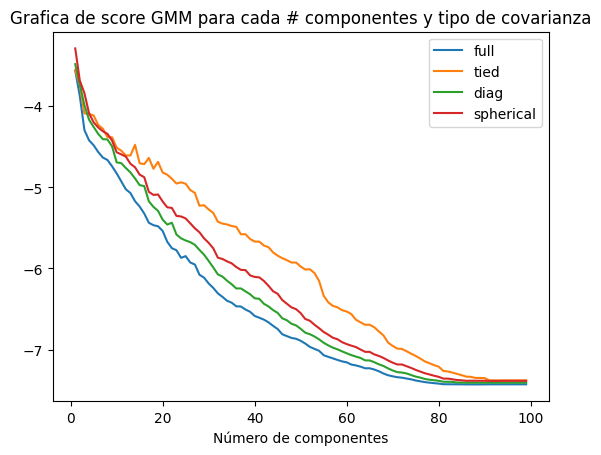

In [17]:
fig, ax = plt.subplots()
colors = plt.cm.tab10(np.arange(0,len(dict_covariance_type)))

for i,(k,models) in enumerate(dict_covariance_type.items()):
    ax.plot(n_components, [-m.score(X) for m in models], label=k, color = colors[i])

plt.xlabel('Número de componentes')    
plt.legend()
plt.title("Grafica de score GMM para cada # componentes y tipo de covarianza")
plt.show()

**Grafica de AIC y BIC** para obtener mayor informacion y elegir un numero de componentes adecuado

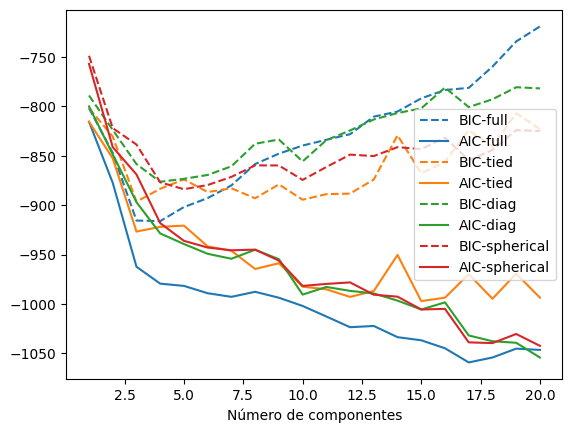

In [18]:
fig, ax = plt.subplots()
colors = plt.cm.tab10(np.arange(0,len(dict_covariance_type)*2))

# iterar por cada elemento del diccionario anterior
for i,(k,models) in enumerate(dict_covariance_type.items()):

    ax.plot(n_components[:20], [m.bic(X) for m in models[:20]], label='BIC-{}'.format(k), color=colors[i], linestyle="--")
    ax.plot(n_components[:20], [m.aic(X) for m in models[:20]], label='AIC-{}'.format(k), color=colors[i])

plt.xlabel('Número de componentes')    
plt.legend(loc='best')
plt.show()

**Ejercicio con gridsearch** \
a continuacion se realiza el ejercicio de encontrar la mejor metrica a travez de Gridsearch con BIC como score para determinar el mejor modelo, sin embargo vemos que el mejor resultado es 92 componentes, lo cual puede que no brinde un valor real al analisis ya que esta cifra es muy cercana al numero total de datos recolectados. por ello seguimos el analisis hecho a priori descrito a continuacion 

In [ ]:
from sklearn.model_selection import GridSearchCV


def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": np.arange(1, 100),
    "covariance_type": ["full", "tied", "diag", "spherical"],
}
grid_search = GridSearchCV(
    GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
)
grid_search.fit(X)

In [ ]:
df_search = pd.DataFrame(grid_search.cv_results_)[
    ["param_n_components", "param_covariance_type", "mean_test_score"]
]
df_search["mean_test_score"] = df_search["mean_test_score"]
df_search = df_search.rename(
    columns={
        "param_n_components": "Number of components",
        "param_covariance_type": "Type of covariance",
        "mean_test_score": "BIC score",
    }
)
df_search.sort_values(by="BIC score").head()

Se aplica el metodo para distintos numeros de componentes, y distintos tipos de covarianza. para concer un poco mas de los efectos que estos tienen se miro la documentacion en (https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_covariances.html) . Donde se ve que uno de los mas flexibles es el de la metodologia **full**

Se realizan las graficas de verosimilitud y de AIC, BIC para determinar cual sera el numero de componentes optimo. Para el criterio de verosimilitud vemos que los valores se estabilizan por encima de 80 componentes, sin embargo esto seria casi tener un grupo por restaurante. Por lo tanto se utilizaran los criterios de AIC y BIC para determinar los mejores puntos. Con dicho analisis se determina que entre 5 y 8 se pueden obtener buenos valores. 

Adicionalmente vemos que efectivamente el tipo de covarianza **full** es la de mejor desempeño. En conclusion se elige el tipo de covarianza **full** y un tamaño de componentes entre 5 y 8; en este caso sera **6**

#### 3.1. Visualización de los resultados

Visualice las densidades estimadas por el  mejor modelo estimado en la sección anterior usando un mapa de calor interactivo, discuta los resultados.

In [ ]:
n_components = 6
best_GM = GaussianMixture(n_components, covariance_type="full", random_state=3).fit(X)

labels = best_GM.predict(X)
data_gp['cluster']=labels

colors = plt.cm.tab10(np.arange(0,n_components))
colors = ['red',
    'orange',
    'green',
    'purple',
    'cadetblue',
    'pink',
          'aqua',
          'yellow',
          'magenta',
          'lime'
         ]

def colorCall(val):
  val = int(val)
  return colors[val]

map = folium.Map(location = [data_gp.loc[:,"Latitud"].mean(), data_gp.loc[:,"Longitud"].mean()], tiles = "OpenStreetMap", zoom_start = 11)

#capa clusters de teatros
for lat, lon, c in zip(data_gp['Latitud'], data_gp['Longitud'], data_gp['cluster']):
    folium.CircleMarker(
        [lat, lon],
        radius=8,
        fill_color = colorCall(c),
        fill=True,
        color=colorCall(c),
        fill_opacity=0.7,
        popup=c
        ).add_to(map)
    


#Display el mapa
map

In [ ]:
import statsmodels.api as sm
import geojsoncontour

In [ ]:
# crear datos dummy para generar las distintas superficies

x = np.linspace(min(data_gp.Longitud), max(data_gp.Longitud), 100)
y = np.linspace(min(data_gp.Latitud), max(data_gp.Latitud), 100)
xx, yy = np.meshgrid(x, y)
grid = np.column_stack(( xx.flatten(),yy.flatten()))

In [ ]:
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Dibuja un elipse dado la media y varianza"""
    ax = ax or plt.gca()
    
    # Convierte las covarianzas
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    # Dibuja el elipse
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                             angle, color="r", **kwargs))
        
def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X).predict(X)
    colors_arr = [colors[l] for l in labels]
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=colors_arr, s=40, zorder=2)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2)
    ax.axis('equal')
    
    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(pos, covar, alpha=w * w_factor)
        

        
X2 = data_gp[['Longitud','Latitud']].values        
colors = ['red',
        'orange',
        'green',
        'purple',
        'cadetblue',
        'pink',
        'aqua',
        'yellow',
        'magenta',
        'lime']
plot_gmm(best_GM, X2, label=True, ax=None)

In [ ]:
import scipy

plt.figure() 

#Transformacion a contornos y geojson
pos = np.dstack((xx, yy))
gmm = 0
for k in range(len(best_GM.weights_)):
    mix_comp = scipy.stats.multivariate_normal(best_GM.means_[k,:].ravel(), best_GM.covariances_[k,:,:])
    gmm += best_GM.weights_[k]*mix_comp.pdf(pos)

#plt.plot(x, y, 'ko', alpha=0.3,color="orange")
contour_heat = plt.contourf(xx, yy, gmm,  alpha = 1.0, zorder=10, levels = 40, cmap="RdYlBu_r")    
# plt.xlim([-8,8]);
# plt.ylim([-6,6]);

geojson_contours = geojsoncontour.contourf_to_geojson(
    contourf=contour_heat,
    min_angle_deg=3.0,
    ndigits=5,
    stroke_width=1,
    fill_opacity=0.1)

In [ ]:
pos = np.dstack((xx, yy))

# Graficamos los puntos
plt.figure()
plt.title("Componentes del MMG")

# Visualizacion del comportamiento de los componentes elegidos
for k in range(len(best_GM.weights_)):
    mvn = scipy.stats.multivariate_normal(best_GM.means_[k,:].ravel(), best_GM.covariances_[k,:,:])
    z = mvn.pdf(pos)
    plt.contour(xx, yy, z,  alpha = 1.0, zorder=10)

plt.show()

In [ ]:
map = folium.Map(location = [data_gp.loc[:,"Latitud"].mean(), data_gp.loc[:,"Longitud"].mean()], tiles = "OpenStreetMap", zoom_start = 11)


for lat, lon, c in zip(data_gp['Latitud'], data_gp['Longitud'], data_gp['cluster']):
    folium.CircleMarker(
        [lat, lon],
        radius=2,
        fill_color = colorCall(c),
        fill=True,
        color=colorCall(c),
        fill_opacity=0.4,
        popup=c
        ).add_to(map)

folium.GeoJson(
    geojson_contours,
    style_function=lambda x: {
        'color':     x['properties']['stroke'],
        'weight':    x['properties']['stroke-width'],
        'fillColor': x['properties']['fill'],
        'lineColor': '#FFFFFF',
        'opacity':   0.9,
    }).add_to(map)



map

Luego de elegir los **6** clusters, se observa como se comporta el GMM, contamos con 5 visualizaciones.

**primera**: mapa donde se indica el grupo al que pertenece cada uno de los restaurantes participantes.
**segunda**: Grafico de elipses que muestra como esta influyendo cada uno de los grupos en el espacio total
**tercera**:Mapa de calor en el cual se ve como una unica representacion la influencia de cada uno de los "cluster"
**cuarta**: nueva representacion de la influencia de cada "cluster" esta vez como *Silhouettes* 
**quinta**: Mapa interacctivo donde se ve un mapa de calor de la ubicacion de los restaurantes participantes en la dinamica de burguer master

Con este mapa se observa que la zona centro de la ciudad es la que tiene una mayor concentracion de restaurantes, en la parte norte y sur sen dos regiones con menor concentracion, la zona al sur esta distribuida de una forma uniforme mientras que la zona en el norte es alargada abarcando de oriente a occidente de la ciudad.

Hay dos grupos ubicados ene la zona cercana al aeropuerto, la mas cercana tiene una mayor concentracion de puntos, mientas que la siguiente es mas dispersa.

La ultima zona corresponde a la ciiudad de chia donde en las bases originales se observa que hay restaurantes participantes

### 4. Comparación con KDE

Estime ahora las densidades usando KDE bivariado de la librería `statsmodels` con el anchos de banda dado por `cv_ml`. Muestre los resultados usando un mapa interactivo. Compare los resultados obtenidos por el "mejor" modelo encontrado via MMG. 

In [ ]:
import statsmodels.api as sm
import geojsoncontour

In [ ]:
kdemultivariate = sm.nonparametric.KDEMultivariate(data=data_gp.loc[:,["Latitud", "Longitud"]], var_type='cc', bw="cv_ml")

In [ ]:
x = np.linspace(min(data_gp.Longitud), max(data_gp.Longitud), 200)
y = np.linspace(min(data_gp.Latitud), max(data_gp.Latitud), 200)
xx, yy = np.meshgrid(x, y)
grid = np.column_stack(( yy.flatten(),xx.flatten()))

In [ ]:
preds_kde_bivariate = kdemultivariate.pdf(data_predict=grid)

In [ ]:
nrows = 1
ncols = int(1/nrows)
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(nrows*6, ncols*5))
#axs = ax.flatten()

#centro_ciudad = (41.881998, -87.627800)


ax.scatter(data_gp.loc[:,"Longitud"], data_gp.loc[:,"Latitud"], color='steelblue', alpha=0.4)
ax.contour(
    xx, yy, preds_kde_bivariate.reshape(xx.shape),
    alpha=0.9
)

ax.set_title('Ubicación y densidad {}'.format(nrows))
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')

plt.show

In [ ]:
contourf = plt.contourf(xx, yy, preds_kde_bivariate.reshape(xx.shape),
        levels=20,alpha =0.9, linestyles='None', cmap="RdYlBu_r")

geojson_contours = geojsoncontour.contourf_to_geojson(
    contourf=contourf,
    min_angle_deg=3.0,
    ndigits=5,
    stroke_width=1,
    fill_opacity=0.1)

In [ ]:
map = folium.Map(location = [data_gp.loc[:,"Latitud"].mean(), data_gp.loc[:,"Longitud"].mean()], tiles = "OpenStreetMap", zoom_start = 11)

folium.GeoJson(
    geojson_contours,
    style_function=lambda x: {
        'color':     x['properties']['stroke'],
        'weight':    x['properties']['stroke-width'],
        'fillColor': x['properties']['fill'],
        'lineColor': '#FFFFFF',
        'opacity':   0.9,
    }).add_to(map)


map

Para este metodo vemos que es mas sensible a la presencia de puntos dispersos, ya que nos muestra mas focos que el metodo de GMM, aunque en éste ultimo se especifica la cantidad de clusters a obtener y la eleccion de este valor puede llegar a ser a subjetiva.

En este caso particular veo mas valor en el metodo de GMM ya que nos permite asociar los puntos a un cluster especifico, nos permite entender la "influencia" de cada cluster identificado a traves de los pesos encontrados por el algoritmo.
A pesar de esto los puntos a favor de KDE es que permite entender otros puntos focales que quizas no son encontrados con GMM ya que en este metodo uno de los parámetros es la cantidad de clusters.